# Estilometría de Ajedrez - CNN Dual-Channel (Descubrimiento Automático)

Este notebook entrena una CNN dual-channel para identificar jugadores basándose en:
- **Canal 1**: Imágenes de tablero con transparencia temporal
- **Canal 2**: Mapas de calor de tiempo de decisión

**NUEVO**: Trabaja con jugadores descubiertos automáticamente (no requiere nombres específicos)

In [11]:
# SETUP
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import tensorflow as tf
from pathlib import Path
from keras import layers, losses, optimizers, metrics, Model
from keras.applications import resnet

print("TF version:", tf.__version__)

# Configurar GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"GPU configurada: {len(gpus)} dispositivo(s)")

# Parámetros
IMG_SHAPE = (192, 192)
BATCH_SIZE = 32
EPOCHS = 100
SEED = 314

# Reproducibilidad
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

TF version: 2.20.0
GPU configurada: 1 dispositivo(s)


## Descubrimiento Automático de Jugadores

El sistema detecta automáticamente los jugadores procesados.
No necesitas conocer sus nombres de antemano.

In [2]:
# Ejecutar el pipeline de estilometría correctamente usando la clase definida en pipeline_stylometry.py
from pathlib import Path
import sys

# Asegurar que el directorio padre (labs/) esté en sys.path para poder importar pipeline_stylometry
# Este notebook está en labs/notebooks/, mientras que pipeline_stylometry.py está en labs/
sys.path.insert(0, str(Path('..').resolve()))

from pipeline_stylometry import ChessStylometryPipeline

pipeline = ChessStylometryPipeline(
    massive_pgn=Path("dataset/generated/lichess_db.pgn"),
    output_base=Path("output/stylometry_results"),
    num_players=20,
    games_per_player=30,
    min_threshold=0.7,
    seed=42
)

# Ejecutar (esto devolverá un diccionario con estadísticas por jugador)
stats = pipeline.run()
print("Pipeline finished. Summary:", stats)


Resolved PGN path relative to pipeline file: /home/andrewyernau/dev/jupyter/labs/dataset/generated/lichess_db.pgn

######################################################################
# PIPELINE DE ESTILOMETRÍA CONDUCTUAL DE AJEDREZ
######################################################################


FASE 1: EXTRACCIÓN DE PARTIDAS POR JUGADOR


FASE 1: DESCUBRIMIENTO DE JUGADORES (PARALELO)
Escaneando hasta 50,000 partidas...
Buscando jugadores únicos...

🚀 Procesamiento PARALELO activado:
   CPU cores: 72
   Threads disponibles: 72
   Workers utilizados: 72
   Chunks: 72
   Tamaño del archivo: 188.34 GB

  ✓ Chunk 0: 147 partidas procesadas
  ✓ Chunk 1: 154 partidas procesadas
  ✓ Chunk 2: 145 partidas procesadas
  ✓ Chunk 3: 144 partidas procesadas
  ✓ Chunk 4: 148 partidas procesadas
  ✓ Chunk 5: 150 partidas procesadas
  ✓ Chunk 6: 150 partidas procesadas
  ✓ Chunk 7: 147 partidas procesadas
  ✓ Chunk 8: 148 partidas procesadas
  ✓ Chunk 9: 155 partidas procesadas
  ✓ Chunk 1

✗ Joeflye_123 game 1: [CHESS_CNN] La partida tiene solo 11 movimientos, pero se solicitaron movimientos 15-23✗ Eve314 game 1: [CHESS_CNN] La partida tiene solo 19 movimientos, pero se solicitaron movimientos 15-23
✗ sanj123456 game 1: [CHESS_CNN] La partida tiene solo 15 movimientos, pero se solicitaron movimientos 15-23

✗ Joeflye_123 game 2: [CHESS_CNN] La partida tiene solo 16 movimientos, pero se solicitaron movimientos 15-23
✗ Mijeho game 1: [CHESS_CNN] La partida tiene solo 15 movimientos, pero se solicitaron movimientos 15-23
✗ Eve314 game 2: [CHESS_CNN] La partida tiene solo 22 movimientos, pero se solicitaron movimientos 15-23


✓ Odessacoach_game01.png (224x224)
✓ chincha_74_game01.png (224x224)
✓ TonyFalcon_game01.png (224x224)
✓ AliAslan2013_game01.png (224x224)
✓ nubihar_game01.png (224x224)
✓ Joeflye_123_game03.png (224x224)
✓ Cr_AKL_game01.png (224x224)
✓ Kluva_matic_game01.png (224x224)
✓ JueAllen_game01.png (224x224)
✓ isnogud42_game01.png (224x224)
✓ Vetko_game01.png (224x224)
✓ Anthony_Hans_game01.png (224x224)
✓ Miss_Claire_game01.png (224x224)
✓ sanj123456_game02.png (224x224)
✓ AgingAimlessly_game01.png (224x224)
✓ Gulerarda576_game01.png (224x224)
✓ Agonb21_game01.png (224x224)✓ Leeuw7_game01.png (224x224)
✓ Rufustheruffian_game01.png (224x224)

✓ CelestialSilver_game01.png (224x224)
✓ belalnabi_game01.png (224x224)✓ Mihribanahmetoglu_game01.png (224x224)

✓ JORGEmath_game01.png (224x224)✓ kabashi_game01.png (224x224)

✓ vatzig_game01.png (224x224)


✗ vatzig game 2: [CHESS_CNN] La partida tiene solo 21 movimientos, pero se solicitaron movimientos 15-23

✓ Mat66_game01.png (224x224)

...

✓ ernesto_che_game21.png (224x224)
✓ Zapata79_game21.png (224x224)
✓ hhperez_game23.png (224x224)
✓ Vikings00_game19.png (224x224)
✓ SDK_UB_game26.png (224x224)
✓ GreekFlager_game18.png (224x224)
✓ Davidothagreat_II_game18.png (224x224)
✓ LeTyr_game24.png (224x224)
✓ sahfateke_game26.png (224x224)
✓ Renegade_247_game21.png (224x224)
✓ WildSeal25_game21.png (224x224)
✓ ernesto_che_game22.png (224x224)
✓ hhperez_game24.png (224x224)
✓ Vikings00_game20.png (224x224)
✓ GreekFlager_game19.png (224x224)
✓ SDK_UB_game27.png (224x224)
✓ sahfateke_game27.png (224x224)
✓ Davidothagreat_II_game19.png (224x224)
✓ LeTyr_game25.png (224x224)
✓ WildSeal25_game22.png (224x224)
✓ Renegade_247_game22.png (224x224)
✓ ernesto_che_game23.png (224x224)
✓ hhperez_game25.png (224x224)
✓ Vikings00_game21.png (224x224)
✓ GreekFlager_game20.png (224x224)
✓ sahfateke_game28.png (224x224)
✓ Davidothagreat_II_game20.png (224x224)
✓ SDK_UB_game28.png (224x224)
✓ WildSeal25_game23.png (224x224)


✗ WildSeal25 game 24: [CHESS_CNN] La partida tiene solo 7 movimientos, pero se solicitaron movimientos 15-23


✓ LeTyr_game26.png (224x224)
✓ Renegade_247_game23.png (224x224)
✓ ernesto_che_game24.png (224x224)
✓ hhperez_game26.png (224x224)
✓ SDK_UB_game29.png (224x224)
✓ WildSeal25_game25.png (224x224)
✓ sahfateke_game29.png (224x224)
✓ Vikings00_game22.png (224x224)
✓ GreekFlager_game21.png (224x224)
✓ Davidothagreat_II_game21.png (224x224)
✓ LeTyr_game27.png (224x224)
✓ ernesto_che_game25.png (224x224)
✓ Renegade_247_game24.png (224x224)
✓ hhperez_game27.png (224x224)
✓ WildSeal25_game26.png (224x224)
✓ sahfateke_game30.png (224x224)
✓ SDK_UB_game30.png (224x224)
✓ GreekFlager_game22.png (224x224)
✓ Vikings00_game23.png (224x224)
✓ Davidothagreat_II_game22.png (224x224)
✓ LeTyr_game28.png (224x224)
✓ ernesto_che_game26.png (224x224)
✓ Renegade_247_game25.png (224x224)
✓ WildSeal25_game27.png (224x224)
✓ hhperez_game28.png (224x224)
✓ Vikings00_game24.png (224x224)
✓ GreekFlager_game23.png (224x224)
✓ Davidothagreat_II_game23.png (224x224)
✓ ernesto_che_game27.png (224x224)
✓ LeTyr_game29.pn

IOPub message rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_msg_rate_limit`.

Current values:
ServerApp.iopub_msg_rate_limit=1000.0 (msgs/sec)
ServerApp.rate_limit_window=3.0 (secs)



✓ Procesadas: 10/10
✓ Procesadas: 10/10
✓ Procesadas: 20/20
⚠ luciferkkkk game 21: Sin datos de tiempo
✓ Procesadas: 10/10
✓ Procesadas: 10/10
✓ Procesadas: 20/20
✓ Procesadas: 30/30

Mapas de calor generados: 30
Guardados en: output/stylometry_results/heatmap_images/Chessisnotboring
Leyenda de gradiente: output/stylometry_results/heatmap_images/Chessisnotboring/colormap_legend.png


GENERANDO MAPAS DE CALOR DE DECISIÓN
Archivo: cryo-phoenix.pgn
Rango de movimientos: 15-23
Grid: 8x8 (tablero estándar)
Tamaño salida: 224x224 píxeles
Tipo: Tiempos relativos (%)
Gradiente: Azul (rápido) → Rojo (lento)

✓ Procesadas: 10/10
⚠ cryo-phoenix game 15: Sin datos de tiempo
✓ Procesadas: 20/21
⚠ cryo-phoenix game 26: Sin datos de tiempo

Mapas de calor generados: 28
Guardados en: output/stylometry_results/heatmap_images/cryo-phoenix
Leyenda de gradiente: output/stylometry_results/heatmap_images/cryo-phoenix/colormap_legend.png


GENERANDO MAPAS DE CALOR DE DECISIÓN
Archivo: AngelTrimino.pgn
Rango 

In [3]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path('..').resolve()))
# Directorios
base_dir = Path("/home/andrewyernau/dev/jupyter/labs/notebooks/output/stylometry_results")
board_images_dir = base_dir / "board_images"
heatmap_images_dir = base_dir / "heatmap_images"

# Descubrir jugadores automáticamente
discovered_players = []
if board_images_dir.exists():
    discovered_players = [d.name for d in board_images_dir.iterdir() if d.is_dir()]

print(f"Jugadores descubiertos: {len(discovered_players)}")
for i, player in enumerate(sorted(discovered_players), 1):
    # Contar imágenes
    board_count = len(list((board_images_dir / player).glob("*.png")))
    heatmap_count = len(list((heatmap_images_dir / player).glob("*.png")))
    print(f"  {i:2d}. {player}: {board_count} tableros, {heatmap_count} heatmaps")

if len(discovered_players) < 2:
    raise ValueError("Se necesitan al menos 2 jugadores. Ejecuta primero el pipeline.")

Jugadores descubiertos: 213
   1. AMIR_HMN7: 24 tableros, 25 heatmaps
   2. Abu_Ubeida_Palestine: 29 tableros, 30 heatmaps
   3. Adal_Berto: 27 tableros, 31 heatmaps
   4. AgingAimlessly: 30 tableros, 31 heatmaps
   5. Agonb21: 30 tableros, 31 heatmaps
   6. Ahmad0123456789: 29 tableros, 30 heatmaps
   7. Ahmed_Real: 30 tableros, 31 heatmaps
   8. Alainjony: 29 tableros, 31 heatmaps
   9. AleksandarGavrilov: 29 tableros, 29 heatmaps
  10. AliAslan2013: 29 tableros, 31 heatmaps
  11. Alle_Amy: 28 tableros, 30 heatmaps
  12. Alomdaashhat: 29 tableros, 30 heatmaps
  13. Amirhossein1389012: 30 tableros, 31 heatmaps
  14. An_op_username: 25 tableros, 25 heatmaps
  15. AngelColina14: 30 tableros, 31 heatmaps
  16. AngelTrimino: 29 tableros, 31 heatmaps
  17. Anthony_Hans: 29 tableros, 31 heatmaps
  18. Anze_AVM: 30 tableros, 31 heatmaps
  19. Arielchezz77: 30 tableros, 31 heatmaps
  20. ArtyClark2014: 29 tableros, 30 heatmaps
  21. Ashyna16: 27 tableros, 28 heatmaps
  22. Bbikdeli: 29 tabler

## Preparación de Datos

Organiza automáticamente los datos en triplets:
- **Anchor**: Partida del jugador A
- **Positive**: Otra partida del mismo jugador A
- **Negative**: Partida de otro jugador

In [4]:
def load_player_images(player_name, board_dir, heatmap_dir):
    """Carga todas las imágenes de un jugador."""
    player_board_dir = board_dir / player_name
    player_heatmap_dir = heatmap_dir / player_name
    
    boards = sorted([str(f) for f in player_board_dir.glob("*.png")])
    heatmaps = sorted([str(f) for f in player_heatmap_dir.glob("*.png")])
    
    # Asegurar pares completos
    min_count = min(len(boards), len(heatmaps))
    return boards[:min_count], heatmaps[:min_count]

# Cargar datos de todos los jugadores
player_data = {}
for player in discovered_players:
    boards, heatmaps = load_player_images(player, board_images_dir, heatmap_images_dir)
    player_data[player] = {'boards': boards, 'heatmaps': heatmaps}
    print(f"{player}: {len(boards)} pares de imágenes")

total_images = sum(len(data['boards']) for data in player_data.values())
print(f"\nTotal de imágenes: {total_images}")

dob20102005: 30 pares de imágenes
AngelColina14: 30 pares de imágenes
AleksandarGavrilov: 29 pares de imágenes
emilian12345: 28 pares de imágenes
Alomdaashhat: 29 pares de imágenes
Priyanka003: 29 pares de imágenes
Olivettimaster: 29 pares de imágenes
Laciproflo: 30 pares de imágenes
ZhorJorge: 30 pares de imágenes
cryo-phoenix: 26 pares de imágenes
Luaksanops: 30 pares de imágenes
Evlikk: 26 pares de imágenes
RAHJazz: 29 pares de imágenes
Ahmed_Real: 30 pares de imágenes
Hexel2: 30 pares de imágenes
makeMeCry: 28 pares de imágenes
driasxfey: 28 pares de imágenes
Vetko: 29 pares de imágenes
Raul507: 30 pares de imágenes
rabihawad777: 30 pares de imágenes
kjhack62: 28 pares de imágenes
TheWinchester1: 29 pares de imágenes
JORGEmath: 29 pares de imágenes
oskarov53: 30 pares de imágenes
Hackersigma: 29 pares de imágenes
KingMaxxxxx: 30 pares de imágenes
N3tinho5oares81: 29 pares de imágenes
kabashi: 30 pares de imágenes
Cavilante: 29 pares de imágenes
Anthony_Hans: 29 pares de imágenes
Sp

In [5]:
def create_triplets_auto(player_data, num_triplets=None):
    """Crea triplets automáticamente desde múltiples jugadores."""
    anchor_boards, anchor_heatmaps = [], []
    positive_boards, positive_heatmaps = [], []
    negative_boards, negative_heatmaps = [], []
    
    players = list(player_data.keys())
    
    # Determinar número de triplets
    if num_triplets is None:
        # Usar el mínimo número de imágenes entre todos los jugadores
        min_images = min(len(data['boards']) for data in player_data.values())
        num_triplets = min_images * len(players) // 2
    
    for _ in range(num_triplets):
        # Seleccionar jugador aleatorio para anchor y positive
        anchor_player = random.choice(players)
        player_images = player_data[anchor_player]
        
        # Necesitamos al menos 2 imágenes del mismo jugador
        if len(player_images['boards']) < 2:
            continue
        
        # Seleccionar anchor y positive del mismo jugador
        idx_anchor, idx_positive = random.sample(range(len(player_images['boards'])), 2)
        
        anchor_boards.append(player_images['boards'][idx_anchor])
        anchor_heatmaps.append(player_images['heatmaps'][idx_anchor])
        positive_boards.append(player_images['boards'][idx_positive])
        positive_heatmaps.append(player_images['heatmaps'][idx_positive])
        
        # Seleccionar negative de otro jugador
        other_players = [p for p in players if p != anchor_player]
        negative_player = random.choice(other_players)
        negative_images = player_data[negative_player]
        
        idx_negative = random.randint(0, len(negative_images['boards']) - 1)
        negative_boards.append(negative_images['boards'][idx_negative])
        negative_heatmaps.append(negative_images['heatmaps'][idx_negative])
    
    return (
        anchor_boards, anchor_heatmaps,
        positive_boards, positive_heatmaps,
        negative_boards, negative_heatmaps
    )

# Crear triplets
(
    anchor_boards, anchor_heatmaps,
    positive_boards, positive_heatmaps,
    negative_boards, negative_heatmaps
) = create_triplets_auto(player_data)

print(f"Triplets creados: {len(anchor_boards)}")

Triplets creados: 426


In [6]:
def preprocess_image(filename, img_shape=IMG_SHAPE):
    """Carga y preprocesa una imagen."""
    image_string = tf.io.read_file(filename)
    image = tf.image.decode_png(image_string, channels=3)
    image = tf.image.convert_image_dtype(image, tf.float32)
    image = tf.image.resize(image, img_shape)
    return image

def preprocess_dual_channel_triplets(
    anchor_board, anchor_heatmap,
    positive_board, positive_heatmap,
    negative_board, negative_heatmap
):
    """Preprocesa triplets dual-channel."""
    return (
        preprocess_image(anchor_board),
        preprocess_image(anchor_heatmap),
        preprocess_image(positive_board),
        preprocess_image(positive_heatmap),
        preprocess_image(negative_board),
        preprocess_image(negative_heatmap)
    )

In [7]:
# Crear datasets de TensorFlow
anchor_dataset = tf.data.Dataset.from_tensor_slices((anchor_boards, anchor_heatmaps))
positive_dataset = tf.data.Dataset.from_tensor_slices((positive_boards, positive_heatmaps))
negative_dataset = tf.data.Dataset.from_tensor_slices((negative_boards, negative_heatmaps))

# Combinar en triplets
triplets_dataset = tf.data.Dataset.zip((anchor_dataset, positive_dataset, negative_dataset))

# Preprocesar
triplets_dataset = triplets_dataset.map(
    lambda a, p, n: preprocess_dual_channel_triplets(a[0], a[1], p[0], p[1], n[0], n[1])
)

# Shuffle y batch
triplets_dataset = triplets_dataset.shuffle(1024, seed=SEED)
triplets_dataset = triplets_dataset.batch(BATCH_SIZE)
triplets_dataset = triplets_dataset.prefetch(tf.data.AUTOTUNE)

# Split train/val (80/20)
total_batches = tf.data.experimental.cardinality(triplets_dataset).numpy()
train_size = int(0.8 * total_batches)

train_dataset = triplets_dataset.take(train_size)
val_dataset = triplets_dataset.skip(train_size)

print(f"Train batches: {train_size}")
print(f"Val batches: {total_batches - train_size}")
print(f"Batch size: {BATCH_SIZE}")

I0000 00:00:1761604240.997144 3054296 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 22502 MB memory:  -> device: 0, name: NVIDIA RTX A5000, pci bus id: 0000:02:00.0, compute capability: 8.6


Train batches: 11
Val batches: 3
Batch size: 32


In [8]:
# Samplear negatives para igualar anchors
num_triplets = len(anchor_boards)

rng = np.random.RandomState(seed=42)
negative_indices = rng.choice(len(negative_boards), size=num_triplets, replace=True)

negative_boards_sampled = [negative_boards[i] for i in negative_indices]
negative_heatmaps_sampled = [negative_heatmaps[i] for i in negative_indices]

# Crear datasets de TensorFlow
anchor_dataset = tf.data.Dataset.from_tensor_slices(
    (anchor_boards, anchor_heatmaps)
)

positive_dataset = tf.data.Dataset.from_tensor_slices(
    (positive_boards, positive_heatmaps)
)

negative_dataset = tf.data.Dataset.from_tensor_slices(
    (negative_boards_sampled, negative_heatmaps_sampled)
)

# Combinar en triplets dataset
triplets_dataset = tf.data.Dataset.zip(
    (anchor_dataset, positive_dataset, negative_dataset)
)

# Preprocesar
triplets_dataset = triplets_dataset.map(
    lambda a, p, n: preprocess_dual_channel_triplets(
        a[0], a[1], p[0], p[1], n[0], n[1]
    )
)

# Shuffle y batch
triplets_dataset = triplets_dataset.shuffle(1024, seed=42)
triplets_dataset = triplets_dataset.batch(BATCH_SIZE)
triplets_dataset = triplets_dataset.prefetch(tf.data.AUTOTUNE)

# Split train/val (80/20)
num_batches = len(list(triplets_dataset))
train_size = int(0.8 * num_batches)

train_dataset = triplets_dataset.take(train_size)
val_dataset = triplets_dataset.skip(train_size)

print(f"\nDatasets creados:")
print(f"  Train batches: {train_size}")
print(f"  Val batches: {num_batches - train_size}")
print(f"  Batch size: {BATCH_SIZE}")


Datasets creados:
  Train batches: 11
  Val batches: 3
  Batch size: 32


2025-10-27 22:30:45.307103: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Arquitectura Dual-Channel Siamese Network

La red procesa dos canales por separado y combina sus embeddings.

In [9]:
class DualChannelEmbedding(Model):
    """Red de embedding con dos canales: tablero y heatmap."""
    
    def __init__(self):
        super().__init__()
        
        # Encoder para imágenes de tablero (ResNet50)
        base_cnn_board = resnet.ResNet50(
            weights="imagenet",
            input_shape=IMG_SHAPE + (3,),
            include_top=False
        )
        base_cnn_board.trainable = False  # Freeze initially
        
        # Encoder para heatmaps (ResNet50)
        base_cnn_heatmap = resnet.ResNet50(
            weights="imagenet",
            input_shape=IMG_SHAPE + (3,),
            include_top=False
        )
        base_cnn_heatmap.trainable = False  # Freeze initially
        
        # Cabezales de embedding
        self.board_encoder = tf.keras.Sequential([
            base_cnn_board,
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(128)
        ], name="board_encoder")
        
        self.heatmap_encoder = tf.keras.Sequential([
            base_cnn_heatmap,
            layers.GlobalAveragePooling2D(),
            layers.Dense(256, activation='relu'),
            layers.Dropout(0.3),
            layers.Dense(128)
        ], name="heatmap_encoder")
        
        # Combinador de embeddings
        self.combiner = tf.keras.Sequential([
            layers.Dense(128, activation='relu'),
            layers.Dropout(0.2),
            layers.Dense(64)
        ], name="combiner")
    
    def call(self, board_img, heatmap_img):
        # Codificar cada canal
        board_emb = self.board_encoder(board_img)
        heatmap_emb = self.heatmap_encoder(heatmap_img)
        
        # Concatenar embeddings
        combined = tf.concat([board_emb, heatmap_emb], axis=1)
        
        # Combinar
        final_emb = self.combiner(combined)
        
        # Normalizar L2
        return tf.nn.l2_normalize(final_emb, axis=1)


# Crear modelo
embedding_model = DualChannelEmbedding()

print("✓ Modelo dual-channel creado")

✓ Modelo dual-channel creado


In [10]:
class DualChannelSiameseModel(Model):
    """Red Siamese con arquitectura dual-channel."""
    
    def __init__(self, embedding_model, margin=1.0):
        super().__init__()
        self.embedding_model = embedding_model
        self.margin = margin
        self.loss_tracker = metrics.Mean(name="loss")
    
    def call(self, inputs):
        anchor_board, anchor_heatmap = inputs[0], inputs[1]
        positive_board, positive_heatmap = inputs[2], inputs[3]
        negative_board, negative_heatmap = inputs[4], inputs[5]
        
        anchor_emb = self.embedding_model(anchor_board, anchor_heatmap)
        positive_emb = self.embedding_model(positive_board, positive_heatmap)
        negative_emb = self.embedding_model(negative_board, negative_heatmap)
        
        return anchor_emb, positive_emb, negative_emb
    
    def train_step(self, data):
        with tf.GradientTape() as tape:
            anchor_emb, positive_emb, negative_emb = self(data)
            
            # Triplet loss
            pos_dist = tf.reduce_sum(tf.square(anchor_emb - positive_emb), axis=1)
            neg_dist = tf.reduce_sum(tf.square(anchor_emb - negative_emb), axis=1)
            
            loss = tf.maximum(pos_dist - neg_dist + self.margin, 0.0)
            loss = tf.reduce_mean(loss)
        
        gradients = tape.gradient(loss, self.trainable_weights)
        self.optimizer.apply_gradients(zip(gradients, self.trainable_weights))
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}
    
    def test_step(self, data):
        anchor_emb, positive_emb, negative_emb = self(data)
        
        pos_dist = tf.reduce_sum(tf.square(anchor_emb - positive_emb), axis=1)
        neg_dist = tf.reduce_sum(tf.square(anchor_emb - negative_emb), axis=1)
        
        loss = tf.maximum(pos_dist - neg_dist + self.margin, 0.0)
        loss = tf.reduce_mean(loss)
        
        self.loss_tracker.update_state(loss)
        return {"loss": self.loss_tracker.result()}
    
    @property
    def metrics(self):
        return [self.loss_tracker]


# Crear modelo Siamese
siamese_model = DualChannelSiameseModel(embedding_model, margin=1.0)

# Compilar
siamese_model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001)
)

print("✓ Modelo Siamese dual-channel compilado")

✓ Modelo Siamese dual-channel compilado


## Entrenamiento

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
)

checkpoint = ModelCheckpoint(
    "best_model.keras",
    save_best_only=True,
    monitor="val_loss"
)

# Entrenamiento
history = siamese_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    verbose=1,
    callbacks=[early_stop, lr_scheduler, checkpoint]
)

print("\n✓ Entrenamiento completado")


Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 6s 598ms/step - loss: 0.6598 - val_loss: 0.6899 - learning_rate: 2.5000e-04
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 452ms/step - loss: 0.6091 - val_loss: 0.5380 - learning_rate: 2.5000e-04
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 211ms/step - loss: 0.6219 - val_loss: 0.6338 - learning_rate: 2.5000e-04
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 201ms/step - loss: 0.6033 - val_loss: 0.7221 - learning_rate: 2.5000e-04
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 5s 453ms/step - loss: 0.5850 - val_loss: 0.5235 - learning_rate: 2.5000e-04
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 203ms/step - loss: 0.5739 - val_loss: 0.6161 - learning_rate: 2.5000e-04
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 204ms/step - loss: 0.5746 - val_loss: 0.5741 - learning_rate: 2.5000e-04
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 212ms/step - loss: 0.5712 - val_loss: 0.5871 - learning_rate: 2.5000e-04
Epoch 9/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 2s 206ms/step - loss: 0.5934 - val_loss: 

## Visualización de Datos

Exploramos las imágenes generadas para cada jugador.

Visualizando muestras de imágenes por jugador...



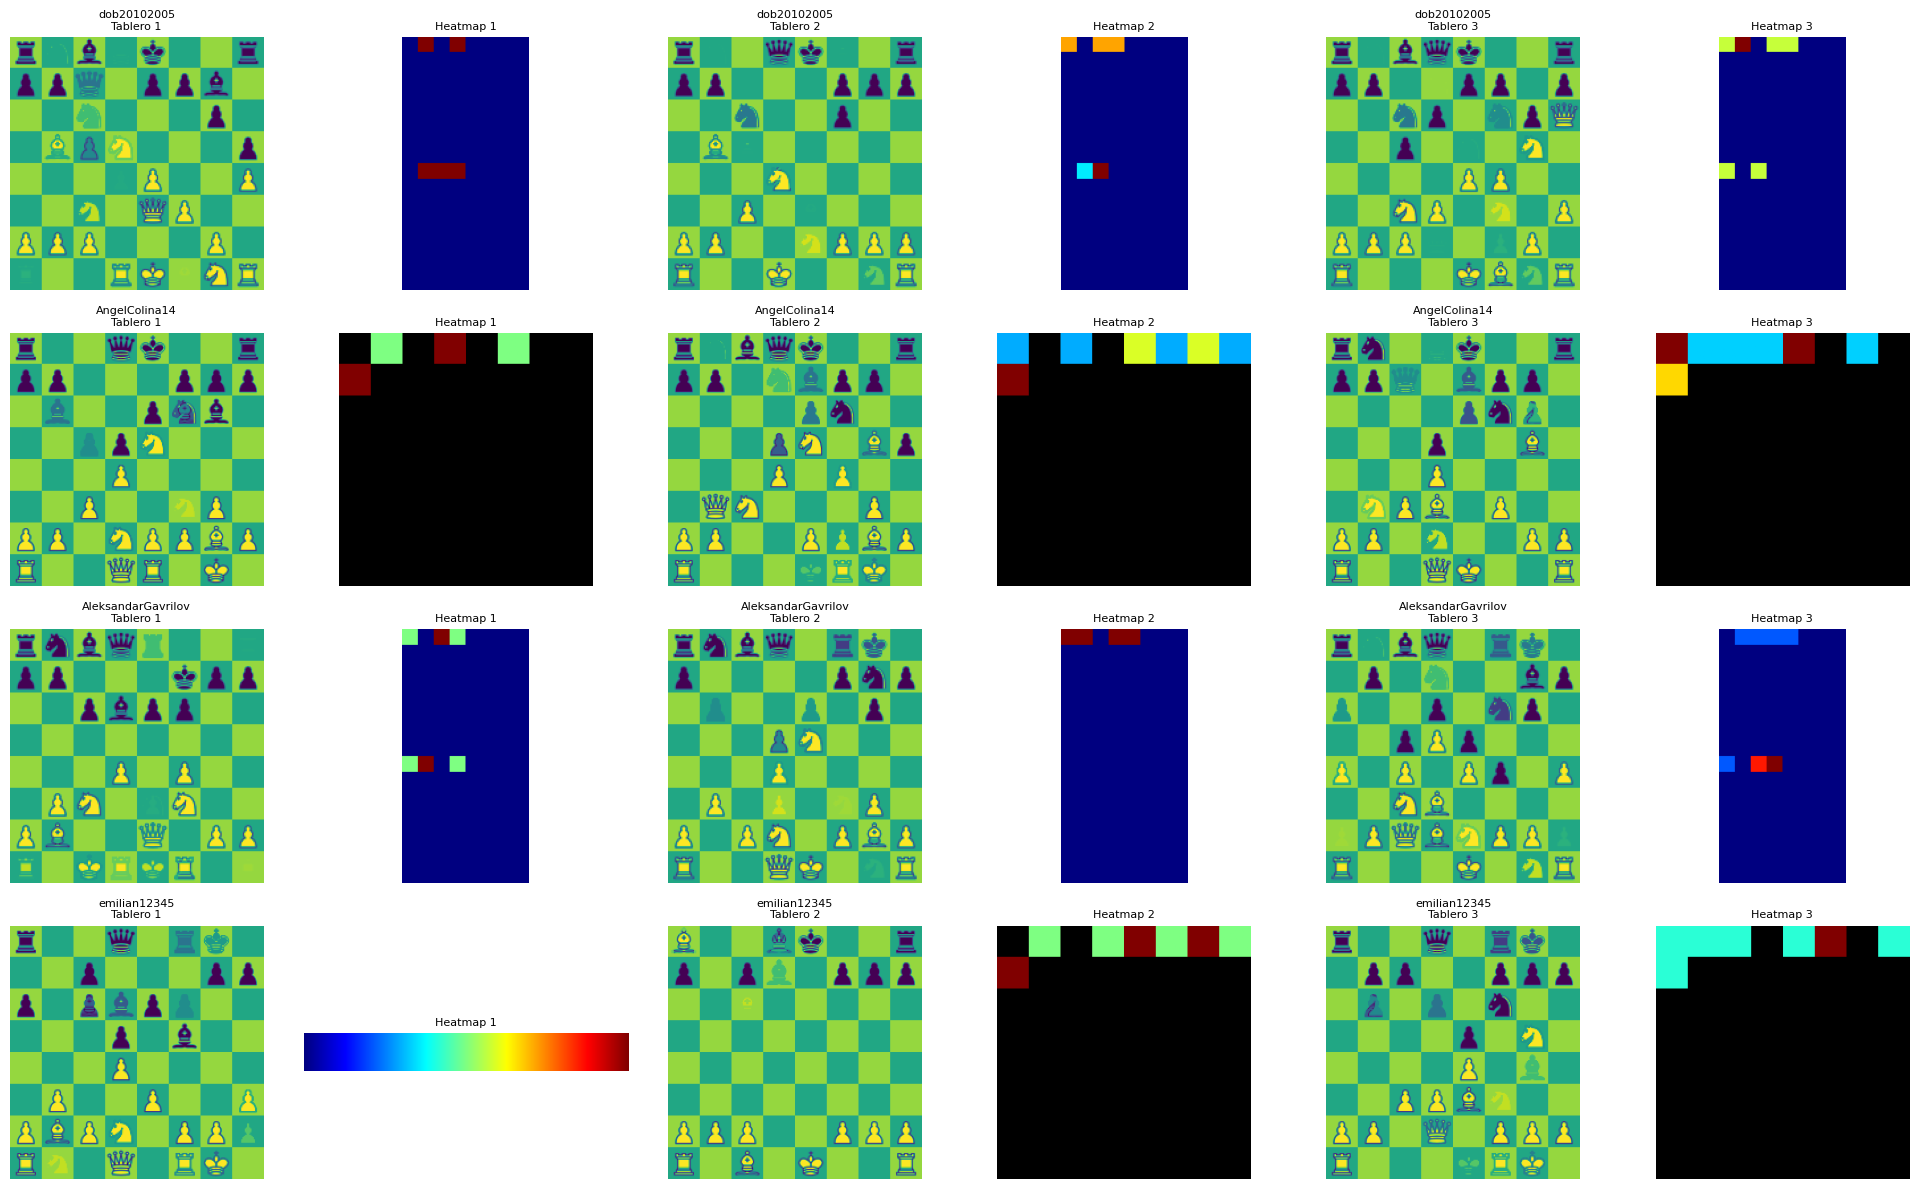

In [15]:
# Visualizar muestras de imágenes
def visualize_player_samples(player_data, num_samples=3):
    """Visualiza muestras de tableros y heatmaps por jugador."""
    num_players = min(4, len(player_data))
    players_to_show = list(player_data.keys())[:num_players]
    
    fig, axes = plt.subplots(num_players, num_samples * 2, figsize=(20, num_players * 3))
    if num_players == 1:
        axes = axes.reshape(1, -1)
    
    for player_idx, player in enumerate(players_to_show):
        data = player_data[player]
        samples = min(num_samples, len(data['boards']))
        
        for sample_idx in range(samples):
            # Board image
            board_img = plt.imread(data['boards'][sample_idx])
            axes[player_idx, sample_idx * 2].imshow(board_img)
            axes[player_idx, sample_idx * 2].set_title(
                f"{player}\nTablero {sample_idx+1}", 
                fontsize=8
            )
            axes[player_idx, sample_idx * 2].axis('off')
            
            # Heatmap image
            heatmap_img = plt.imread(data['heatmaps'][sample_idx])
            axes[player_idx, sample_idx * 2 + 1].imshow(heatmap_img)
            axes[player_idx, sample_idx * 2 + 1].set_title(
                f"Heatmap {sample_idx+1}",
                fontsize=8
            )
            axes[player_idx, sample_idx * 2 + 1].axis('off')
    
    plt.tight_layout()
    plt.show()

print("Visualizando muestras de imágenes por jugador...\n")
visualize_player_samples(player_data, num_samples=3)

## Análisis de Entrenamiento

Visualización de curvas de aprendizaje y métricas.

/tmp/ipykernel_3054296/653934597.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([train_losses, val_losses], labels=['Train', 'Val'])


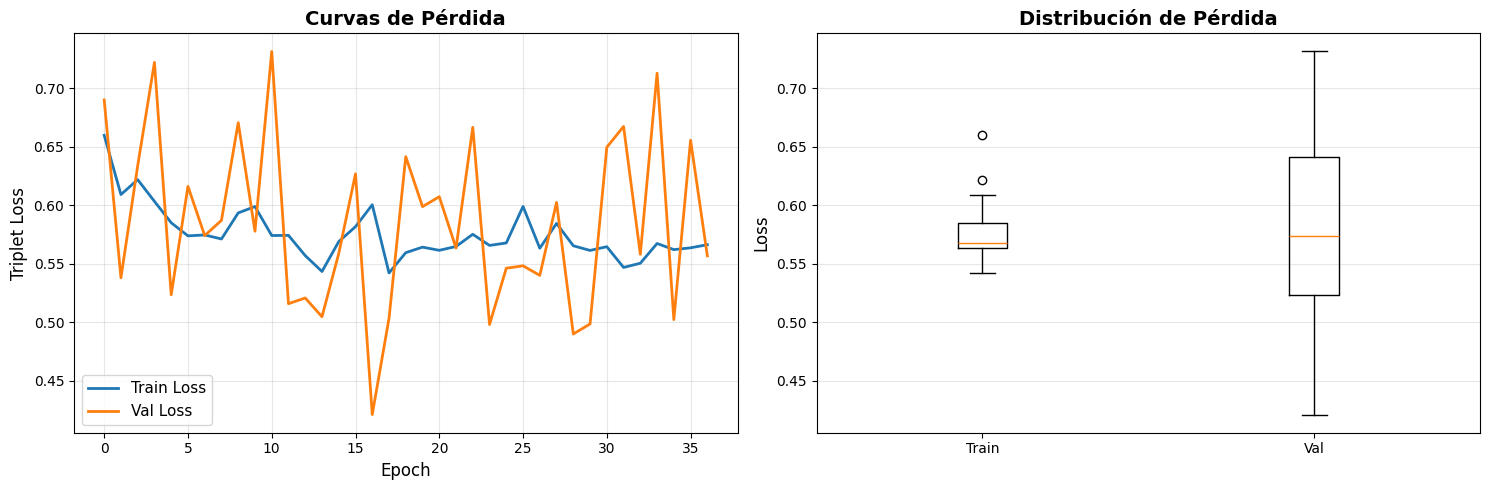


ESTADÍSTICAS DE ENTRENAMIENTO
Loss final (train): 0.5663
Loss final (val): 0.5568
Mejor val loss: 0.4212 (epoch 17)
Overfitting: 0.0095

⚠ MODERADO: Aprendizaje aceptable (0.5 < val loss < 1.0)


In [16]:
# Graficar curvas de entrenamiento
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss curves
axes[0].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0].plot(history.history['val_loss'], label='Val Loss', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Triplet Loss', fontsize=12)
axes[0].set_title('Curvas de Pérdida', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Loss comparison boxplot
train_losses = history.history['loss']
val_losses = history.history['val_loss']
axes[1].boxplot([train_losses, val_losses], labels=['Train', 'Val'])
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Distribución de Pérdida', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Estadísticas de entrenamiento
final_train_loss = train_losses[-1]
final_val_loss = val_losses[-1]
min_val_loss = min(val_losses)
min_val_epoch = val_losses.index(min_val_loss) + 1

print("\n" + "="*70)
print("ESTADÍSTICAS DE ENTRENAMIENTO")
print("="*70)
print(f"Loss final (train): {final_train_loss:.4f}")
print(f"Loss final (val): {final_val_loss:.4f}")
print(f"Mejor val loss: {min_val_loss:.4f} (epoch {min_val_epoch})")
print(f"Overfitting: {abs(final_train_loss - final_val_loss):.4f}")

if final_val_loss < 0.5:
    print("\n✓ EXCELENTE: La red está aprendiendo muy bien (val loss < 0.5)")
elif final_val_loss < 1.0:
    print("\n⚠ MODERADO: Aprendizaje aceptable (0.5 < val loss < 1.0)")
else:
    print("\n✗ INSUFICIENTE: Necesita más entrenamiento (val loss > 1.0)")

print("="*70)

## Análisis de Embeddings

Evaluamos la capacidad de la red para distinguir jugadores.

Calculando embeddings...


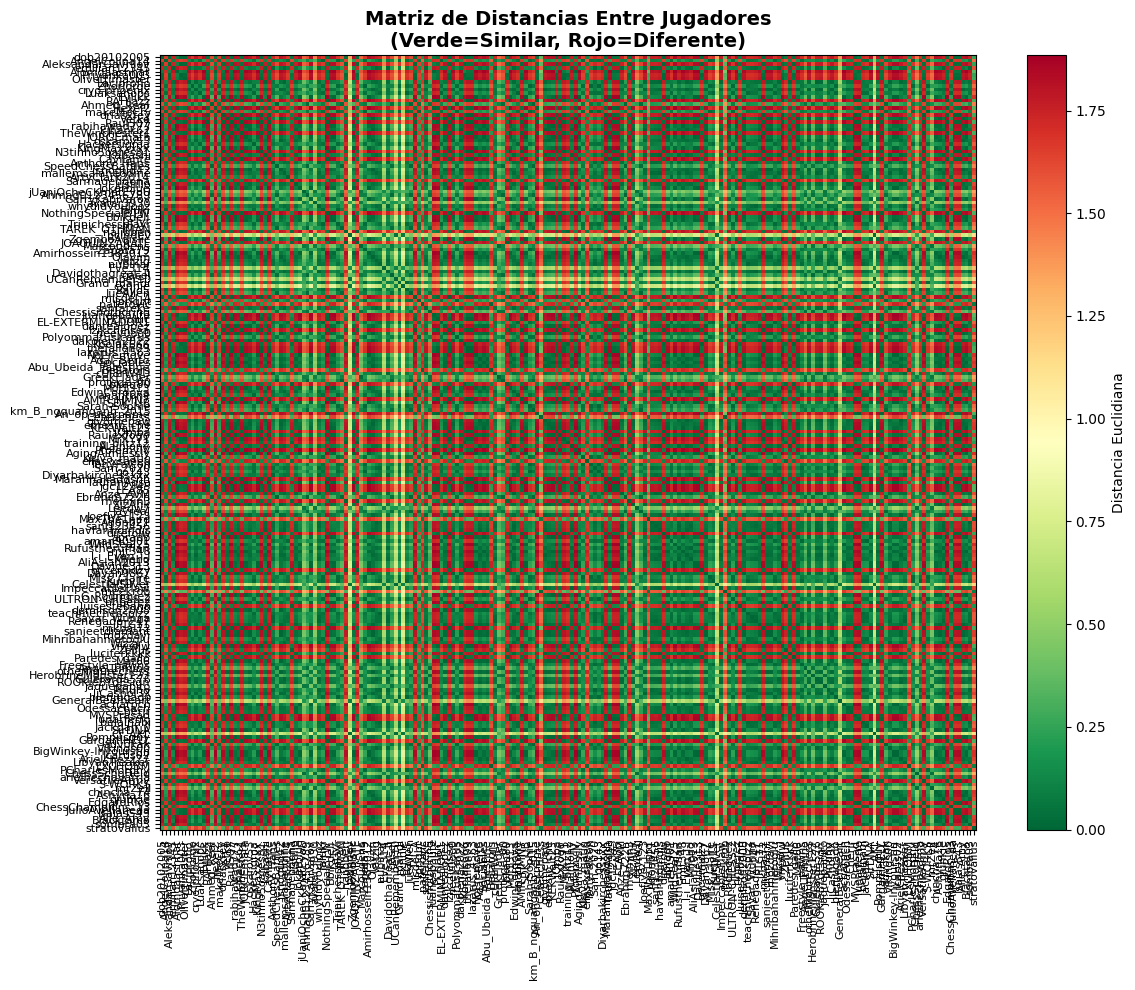


ANÁLISIS DE SEPARABILIDAD
Distancia intra-clase (mismo jugador): 0.0000 ± 0.0000
Distancia inter-clase (otros jugadores): 0.7698 ± 0.7608
Ratio (inter/intra): 7697889401.84x

✓ EXCELENTE: La red distingue muy bien entre jugadores


In [17]:
def compute_distance_matrix(player_data, embedding_model, num_samples=10):
    """Calcula matriz de distancias entre jugadores."""
    players = list(player_data.keys())
    num_players = len(players)
    
    # Matriz de distancias
    dist_matrix = np.zeros((num_players, num_players))
    
    print("Calculando embeddings...")
    # Calcular embeddings promedio por jugador
    player_embeddings = {}
    for player in players:
        boards = player_data[player]['boards'][:num_samples]
        heatmaps = player_data[player]['heatmaps'][:num_samples]
        
        embeddings = []
        for board, heatmap in zip(boards, heatmaps):
            board_img = preprocess_image(board)[None, ...]
            heatmap_img = preprocess_image(heatmap)[None, ...]
            emb = embedding_model(board_img, heatmap_img).numpy()
            embeddings.append(emb[0])
        
        player_embeddings[player] = np.mean(embeddings, axis=0)
    
    # Calcular distancias
    for i, player1 in enumerate(players):
        for j, player2 in enumerate(players):
            dist = np.sqrt(np.sum(
                (player_embeddings[player1] - player_embeddings[player2]) ** 2
            ))
            dist_matrix[i, j] = dist
    
    return dist_matrix, players

# Calcular matriz de distancias
dist_matrix, players_list = compute_distance_matrix(player_data, embedding_model)

# Visualizar matriz
plt.figure(figsize=(12, 10))
im = plt.imshow(dist_matrix, cmap='RdYlGn_r', aspect='auto')
plt.colorbar(im, label='Distancia Euclidiana')
plt.xticks(range(len(players_list)), players_list, rotation=90, fontsize=8)
plt.yticks(range(len(players_list)), players_list, fontsize=8)
plt.title('Matriz de Distancias Entre Jugadores\n(Verde=Similar, Rojo=Diferente)',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Estadísticas
intra_class = np.diagonal(dist_matrix)
inter_class = dist_matrix[np.triu_indices_from(dist_matrix, k=1)]

print("\n" + "="*70)
print("ANÁLISIS DE SEPARABILIDAD")
print("="*70)
print(f"Distancia intra-clase (mismo jugador): {intra_class.mean():.4f} ± {intra_class.std():.4f}")
print(f"Distancia inter-clase (otros jugadores): {inter_class.mean():.4f} ± {inter_class.std():.4f}")
print(f"Ratio (inter/intra): {inter_class.mean() / (intra_class.mean() + 1e-10):.2f}x")

if inter_class.mean() > intra_class.mean() * 1.5:
    print("\n✓ EXCELENTE: La red distingue muy bien entre jugadores")
elif inter_class.mean() > intra_class.mean():
    print("\n⚠ MODERADO: Cierta capacidad de distinción")
else:
    print("\n✗ INSUFICIENTE: No distingue bien entre jugadores")

print("="*70)

## Guardar Modelo

Guardamos el modelo entrenado para uso posterior.

In [19]:
# Guardar modelo de embedding
import time
model_dir = Path("../models")
model_dir.mkdir(exist_ok=True)

timestamp = time.strftime("%Y%m%d_%H%M%S")
model_name = f"auto_discovery_dual_channel_{timestamp}.keras"
model_path = model_dir / model_name

embedding_model.save(model_path)

print(f"✓ Modelo guardado en: {model_path}")
print(f"  Jugadores entrenados: {len(player_data)}")
print(f"  Total de imágenes: {sum(len(d['boards']) for d in player_data.values())}")
print(f"  Val loss final: {final_val_loss:.4f}")

# Guardar metadata
import json
metadata = {
    'model_name': model_name,
    'timestamp': timestamp,
    'num_players': len(player_data),
    'players': list(player_data.keys()),
    'total_images': sum(len(d['boards']) for d in player_data.values()),
    'final_train_loss': float(final_train_loss),
    'final_val_loss': float(final_val_loss),
    'best_val_loss': float(min_val_loss),
    'best_epoch': int(min_val_epoch),
    'epochs': EPOCHS,
    'batch_size': BATCH_SIZE,
    'img_shape': list(IMG_SHAPE),
}

metadata_path = model_dir / f"metadata_{timestamp}.json"
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"✓ Metadata guardada en: {metadata_path}")

✓ Modelo guardado en: ../models/auto_discovery_dual_channel_20251027_230820.keras
  Jugadores entrenados: 213
  Total de imágenes: 6034
  Val loss final: 0.5568
✓ Metadata guardada en: ../models/metadata_20251027_230820.json


## Resumen Final

Resumen completo del experimento.

In [20]:
print("="*70)
print("RESUMEN FINAL DEL EXPERIMENTO")
print("="*70)
print(f"\nDatos:")
print(f"  • Jugadores descubiertos: {len(player_data)}")
print(f"  • Total de partidas: {sum(len(d['boards']) for d in player_data.values())}")
print(f"  • Triplets generados: {len(anchor_boards)}")
print(f"\nEntrenamiento:")
print(f"  • Epochs: {EPOCHS}")
print(f"  • Batch size: {BATCH_SIZE}")
print(f"  • Train batches: {train_size}")
print(f"  • Val batches: {total_batches - train_size}")
print(f"\nResultados:")
print(f"  • Loss final (train): {final_train_loss:.4f}")
print(f"  • Loss final (val): {final_val_loss:.4f}")
print(f"  • Mejor val loss: {min_val_loss:.4f} (epoch {min_val_epoch})")
print(f"  • Ratio inter/intra: {inter_class.mean() / (intra_class.mean() + 1e-10):.2f}x")
print(f"\nModelo:")
print(f"  • Guardado en: {model_path.name}")
print(f"  • Metadata: {metadata_path.name}")
print("\n" + "="*70)
print("✓ EXPERIMENTO COMPLETADO")
print("="*70)

RESUMEN FINAL DEL EXPERIMENTO

Datos:
  • Jugadores descubiertos: 213
  • Total de partidas: 6034
  • Triplets generados: 426

Entrenamiento:
  • Epochs: 100
  • Batch size: 32
  • Train batches: 11
  • Val batches: 3

Resultados:
  • Loss final (train): 0.5663
  • Loss final (val): 0.5568
  • Mejor val loss: 0.4212 (epoch 17)
  • Ratio inter/intra: 7697889401.84x

Modelo:
  • Guardado en: auto_discovery_dual_channel_20251027_230820.keras
  • Metadata: metadata_20251027_230820.json

✓ EXPERIMENTO COMPLETADO
